## 1) 设定环境并读取基本信息
解析 `dataset_info.json` 以动态获取数据特征（通道数、采样点、类别等），消除硬编码。

In [4]:
import json
import h5py
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
import copy
from torch.utils.data import DataLoader

# 假设自定义的 Dataset 路径已正确配置
from course_project.TEST_DATASET import TrainDataset, TestDataset

DATA_NAME = "MDD"
DATA_INFO_PATH = f"course_project/{DATA_NAME}/dataset_info.json"
INDEX_PATH_TRAIN = f"course_project/{DATA_NAME}/train.h5"
INDEX_PATH_VAL = f"course_project/{DATA_NAME}/val.h5"
INDEX_PATH_TEST = f"course_project/{DATA_NAME}/test_x_only.h5"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

num_labels = info["dataset"]["num_labels"]
category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Information ===")
print("Number of Labels:", num_labels)
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

# 动态确定输入特征维度
time_points = int(target_sampling_rate * window_sec)
num_channels = len(channels)
num_classes = num_labels

=== Dataset Information ===
Number of Labels: 2
Categories: ['Healthy Controls', 'Major Depressive Disorder']
Channels (count): 20
Target Sampling Rate (Hz): 200.0
Window Size (sec): 1.0


## 2) 检查数据形状

In [15]:
print("========== 检查训练集 (Train) ==========")
with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查验证集 (Validation) ==========")
with h5py.File(INDEX_PATH_VAL, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))
    
print("\n========== 检查测试集 (Test - X only) ==========")
with h5py.File(INDEX_PATH_TEST, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)

========== 检查训练集 (Train) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (960, 20, 200)
y dtype: int64
y shape: (960,)
unique: [0 1]

========== 检查验证集 (Validation) ==========
keys: ['X', 'y']
x dtype: float32
x shape: (640, 20, 200)
y dtype: int64
y shape: (640,)
unique: [0 1]

========== 检查测试集 (Test - X only) ==========
keys: ['X']
x dtype: float32
x shape: (800, 20, 200)


## 3) 定义模型
最终模型：**EEGMultiScaleResNet**

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class SELayer(nn.Module):
    """标准 Squeeze-and-Excitation 通道注意力模块"""
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)


class MultiScaleConvBlock(nn.Module):
    """多尺度时间卷积块（并行 kernel=3,5,7） + 通道注意力 + 残差连接"""
    def __init__(self, in_channels, out_channels, dilation=1, dropout=0.3):
        super().__init__()
        # 多尺度分支，每个分支先降维再提特征（深度可分离思想）
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//2, 1, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU(),
            nn.Conv1d(out_channels//2, out_channels//2, kernel_size=3, padding=1*dilation,
                      dilation=dilation, groups=out_channels//2, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU()
        )
        self.branch5 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//2, 1, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU(),
            nn.Conv1d(out_channels//2, out_channels//2, kernel_size=5, padding=2*dilation,
                      dilation=dilation, groups=out_channels//2, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU()
        )
        self.branch7 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels//2, 1, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU(),
            nn.Conv1d(out_channels//2, out_channels//2, kernel_size=7, padding=3*dilation,
                      dilation=dilation, groups=out_channels//2, bias=False),
            nn.BatchNorm1d(out_channels//2),
            nn.ELU()
        )
        # 合并后通道 = out_channels//2 * 3 ≈ 1.5*out_channels，用1x1压缩到 out_channels
        self.squeeze = nn.Conv1d(out_channels//2 * 3, out_channels, 1, bias=False)
        self.bn = nn.BatchNorm1d(out_channels)
        self.elu = nn.ELU()
        self.se = SELayer(out_channels)
        self.dropout = nn.Dropout(dropout)

        # 残差连接通道匹配
        self.match = None
        if in_channels != out_channels:
            self.match = nn.Conv1d(in_channels, out_channels, 1, bias=False)

    def forward(self, x):
        residual = x if self.match is None else self.match(x)
        out3 = self.branch3(x)
        out5 = self.branch5(x)
        out7 = self.branch7(x)
        out = torch.cat([out3, out5, out7], dim=1)   # (B, 1.5*out_channels, T)
        out = self.squeeze(out)                      # (B, out_channels, T)
        out = self.bn(out)
        out = self.elu(out)
        out = self.se(out)
        out = self.dropout(out)
        out = out + residual
        return out


class EEGMultiScaleResNet(nn.Module):
    """
    本质改进：多尺度时间卷积 + SE通道注意力 + 膨胀残差块
    适用于 EEG 信号的鲁棒特征提取。
    """
    def __init__(self, num_channels, num_classes):
        super().__init__()
        # Stem：初始特征映射
        self.stem = nn.Sequential(
            nn.Conv1d(num_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.MaxPool1d(2),
            nn.Dropout(0.2)
        )
        # 三个残差块，逐步扩大通道并增大膨胀率
        self.block1 = MultiScaleConvBlock(64, 128, dilation=1, dropout=0.3)
        self.pool1 = nn.MaxPool1d(2)
        self.block2 = MultiScaleConvBlock(128, 256, dilation=2, dropout=0.3)
        self.pool2 = nn.MaxPool1d(2)
        self.block3 = MultiScaleConvBlock(256, 256, dilation=4, dropout=0.3)

        # 全局统计量：平均池化 + 最大池化拼接
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.max_pool = nn.AdaptiveMaxPool1d(1)

        # 分类器：两层 MLP + 强 Dropout
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x: (B, C, T)
        x = self.stem(x)          # (B, 64, T/2)
        x = self.block1(x)        # (B, 128, T/2)
        x = self.pool1(x)         # (B, 128, T/4)
        x = self.block2(x)        # (B, 256, T/4)
        x = self.pool2(x)         # (B, 256, T/8)
        x = self.block3(x)        # (B, 256, T/8)

        avg = self.avg_pool(x)    # (B, 256, 1)
        max = self.max_pool(x)    # (B, 256, 1)
        x = torch.cat([avg, max], dim=1)   # (B, 512, 1)
        return self.classifier(x)

## 4) 配置数据加载器、设备与优化器
设备自适应检测（CUDA GPU / Apple MPS / CPU）

In [18]:
# -------------------------
# 超参数设定
# -------------------------
BATCH_SIZE = 32
EPOCHS = 100          # 增加总 Epoch 数，依靠早停来控制结束
LR = 1e-4
PATIENCE = 20        # 早停的耐心值（验证集持续多少轮不上升则停止）

# -------------------------
# 设定计算设备 (GPU / MPS / CPU)
# -------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# -------------------------
# 准备 DataLoader
# -------------------------
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)   
test_ds = TestDataset(INDEX_PATH_TEST)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 实例化模型、损失函数、优化器
# -------------------------
model = EEGMultiScaleResNet(
    num_channels=num_channels,
    num_classes=num_classes
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# 增加：余弦退火学习率调度器
from torch.optim.lr_scheduler import CosineAnnealingLR
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

Using device: cpu


## 5) 模型训练与验证
实现了 **Early Stopping** 和 **Best Model 保存机制**。避免模型训练到最后已经严重过拟合。

In [19]:
# 用于记录曲线的数组
train_losses, val_losses, train_accuracies, val_accuracies = [], [], [], []

best_val_acc = 0.0
best_model_weights = None
epochs_no_improve = 0
has_saved_model = False
best_model_path = None 

os.makedirs("model_checkpoints", exist_ok=True)

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0  
    train_num = 0

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        data = F.normalize(data, dim=2)   # 对时间维做 L2 归一化
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        train_pred = torch.argmax(output, dim=1)
        train_correct += (train_pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num  
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)     

    # ===== Validation =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_data, val_label = val_data.to(device), val_label.to(device)

            val_data = F.normalize(val_data, dim=2)
            
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    scheduler.step()
    
    # 打印每轮训练结果
    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.2%} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.2%}"
    )

    # ===== 早停与最佳模型保存逻辑 =====
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        epochs_no_improve = 0  # 只要准确率刷新就重置耐心值
        
        # 从第 20 个 epoch 开始，并且超越了历史最佳才实际保存模型
        if epoch + 1 >= 20 and epoch_val_acc > 0.9:
            best_model_weights = copy.deepcopy(model.state_dict())
            # 为文件加上 Val Accuracy 的值作为后缀
            current_model_path = f"model_checkpoints/{DATA_NAME}_best_model_acc{best_val_acc * 100:.2f}.pth"
  
            # 先将删除旧权重，再更新模型路径并保存
            if best_model_path and os.path.exists(best_model_path):
                os.remove(best_model_path)
            best_model_path = current_model_path
            torch.save(best_model_weights, best_model_path)
            has_saved_model = True
            print(f" ---> 出现更高的验证集准确率 ({best_val_acc:.2%})，已更新模型。")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nTriggered Early Stopping at Epoch {epoch+1}!")
            break
            
    if epoch + 1 == 20:
        print(f" ---> 前 20 个 Epoch 结束，目前的最佳验证集准确率为 {best_val_acc:.2%}")

print("\n" + "-" * 40)
print(f"Final Best Val Accuracy: {best_val_acc:.2%}")

# 最终的结果打印判定
if has_saved_model:
    print(f"训练成功结束！最佳模型已保存至: {best_model_path}")
else:
    print("\n【提醒】训练结束但未保存模型！请调整代码。")

Epoch [01/100] | Train Loss: 0.7069 | Train Acc: 57.19% | Val Loss: 0.6806 | Val Acc: 77.66%
Epoch [02/100] | Train Loss: 0.6258 | Train Acc: 65.00% | Val Loss: 0.5563 | Val Acc: 77.97%
Epoch [03/100] | Train Loss: 0.5746 | Train Acc: 70.83% | Val Loss: 0.5062 | Val Acc: 80.16%
Epoch [04/100] | Train Loss: 0.5415 | Train Acc: 76.04% | Val Loss: 0.5054 | Val Acc: 81.88%
Epoch [05/100] | Train Loss: 0.5204 | Train Acc: 77.19% | Val Loss: 0.4904 | Val Acc: 81.09%
Epoch [06/100] | Train Loss: 0.5083 | Train Acc: 79.27% | Val Loss: 0.4870 | Val Acc: 84.69%
Epoch [07/100] | Train Loss: 0.4872 | Train Acc: 80.10% | Val Loss: 0.4770 | Val Acc: 89.22%
Epoch [08/100] | Train Loss: 0.4342 | Train Acc: 84.38% | Val Loss: 0.4340 | Val Acc: 88.75%
Epoch [09/100] | Train Loss: 0.4151 | Train Acc: 86.67% | Val Loss: 0.4216 | Val Acc: 89.84%
Epoch [10/100] | Train Loss: 0.4046 | Train Acc: 87.29% | Val Loss: 0.4014 | Val Acc: 90.31%
Epoch [11/100] | Train Loss: 0.3729 | Train Acc: 89.90% | Val Loss: 0.

## 6) 训练过程可视化

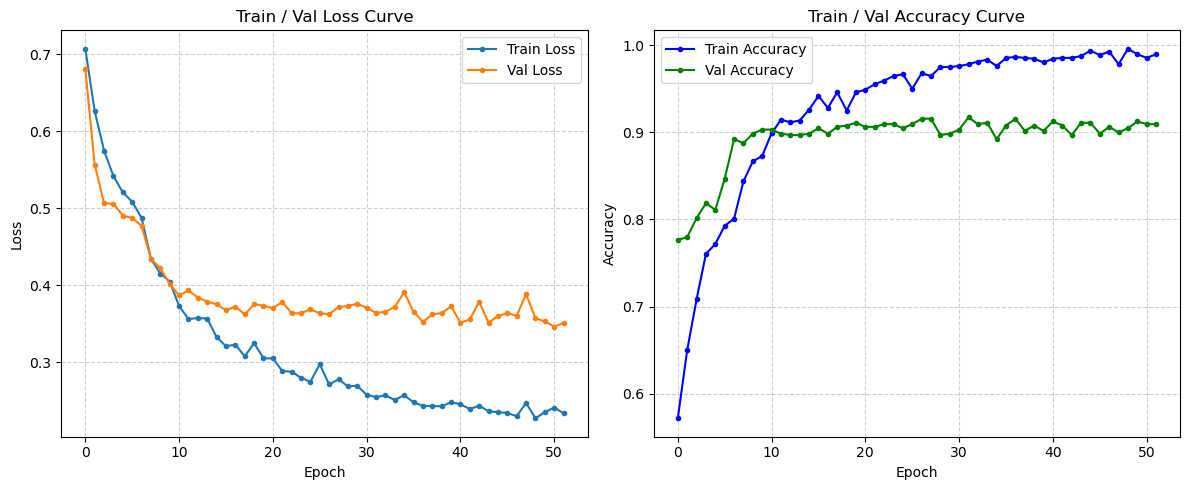

In [20]:
plt.figure(figsize=(12, 5))

# 绘制 Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker='o', markersize=3)
plt.plot(val_losses, label="Val Loss", marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Val Loss Curve")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 绘制 Accuracy 曲线
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", marker='o', markersize=3, color='blue')
plt.plot(val_accuracies, label="Val Accuracy", marker='o', markersize=3, color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Train / Val Accuracy Curve") 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

## 7) 测试集推理与结果生成
执行测试推理前，将回载上面跑出来的“最佳验证集权重”，以此来产出最终提交的结果。

In [21]:
os.makedirs("final_result", exist_ok=True)
# -------------------------
# 加载最佳模型权重
# -------------------------
# 方式 1 ：使用训练过程中保存的最佳模型路径
model_path = best_model_path  
# 方式 2 ：手动指定 model_checkpoints 文件夹下的模型路径
# model_path = "model_checkpoints/CHINESE_best_model_acc51.50.pth"  

print(f"Loading best model from {model_path} for testing...")
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))

model.eval()

output_path = f'final_result/{DATA_NAME}.txt'
all_test_labels = []

with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_data = test_data.to(device)
        test_data = F.normalize(test_data, dim=2)
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

# 保存 test 预测标签（每行一个数字）
with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

Loading best model from model_checkpoints/MDD_best_model_acc91.72.pth for testing...
Saved 800 labels to: final_result/MDD.txt
